<a href="https://colab.research.google.com/github/DiyaZahra/taxi_fare_prediction/blob/main/taxi_fare_nyc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NYC Fare Prediction: Yellow, Green, Uber and Lyft (2024)

**Goal:** predict the fare of an NYC trip from only what a rider knows *before* the trip: pickup zone, dropoff zone, date and time, and the weather. The same model compares the expected fare across four services.

**Data (all public)**
- NYC TLC trip records for **Yellow taxi, Green taxi and High-Volume For-Hire Vehicles (Uber / Lyft)**, all 12 months of 2024
- **Open-Meteo** hourly weather for NYC (temperature, rain, snow, wind, cloud cover)

**What this notebook does**
1. Downloads and cleans 12 months of trips (about 5.2 million sampled trips, balanced across the four services)
2. Engineers **demand** (trips per zone-hour), a **supply proxy** (average traffic speed) and **weather risk flags**
3. Splits train / test by calendar (the 15th-21st of every month is held out)
4. Checks the linear-regression assumptions (target skew, VIF)
5. Fits OLS, Ridge and Lasso on the log of the fare, then improves the distance terms
6. Evaluates on the held-out weeks and saves the artifacts used by the Streamlit app

**Final result (held-out weeks, never seen during training)**

| Model | R² | RMSE | MAE |
|---|---|---|---|
| OLS / Ridge / Lasso, straight-line distance | 0.671 | $17.16 | $6.79 |
| **Ridge + log/squared distance (final)** | **0.758** | **$8.82** | **$4.93** |

Run it in Google Colab. Intermediate files are stored in Google Drive, so the run can resume after a disconnect (months already processed are skipped). The first full run takes about an hour, mostly downloading the large Uber/Lyft files.

## 1. Setup

In [ ]:
import os, shutil, urllib.request
import numpy as np, pandas as pd, pyarrow.parquet as pq, requests
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')
folder = "/content/drive/MyDrive/nyc_taxi_project"   # every intermediate file is saved here
os.makedirs(folder, exist_ok=True)

Mounted at /content/drive


## 2. Download, sample and clean one month at a time

`process_month` handles one month end to end.

- **Demand is counted on the full data first, then the data is sampled.** If Uber/Lyft were sampled first, the demand counts would be about 30x too small.
- The Uber/Lyft file is around 20 million rows per month, so it is saved to disk and read in chunks. Only a 3% sample is kept for modelling.
- **Target = base fare only** (no tips, tolls, taxes or fees), so all four services are comparable. Metered taxi fares and Uber/Lyft dynamic prices are still different things.

**Cleaning rules** (checked on January 2024 first):
- fare must be between $0 and $200: negative fares are refunds (minimum was -$899). The 1,070 January trips above $200 had a median distance of about 42 miles, i.e. out-of-city rides that are outside the scope of a city fare model
- distance between 0 and 100 miles, duration between 1 and 180 minutes
- zones 264 / 265 are "Unknown" and are removed
- rows dated outside the month are removed
- Green taxis lost about 7% of rows (mostly zero-distance / under-one-minute trips, i.e. cancelled rides); Uber and Lyft lost about 0.2%

In [ ]:
BASE = "https://d37ci6vzurychx.cloudfront.net/trip-data/{}_tripdata_{}.parquet"

def std(df, service, pick, drop, dist, fare):
    """Bring every service into one common table layout."""
    return pd.DataFrame({
        "service": service,
        "pickup_time": df[pick],
        "PULocationID": df["PULocationID"],
        "DOLocationID": df["DOLocationID"],
        "distance": df[dist],
        "fare": df[fare],
        "duration_min": (df[drop] - df[pick]).dt.total_seconds() / 60,
    })

def process_month(ym):
    """Download one month, count demand, sample, clean and save it."""
    # Yellow + Green taxis (small enough to load fully, only the needed columns)
    y = pd.read_parquet(BASE.format("yellow", ym), columns=[
        "tpep_pickup_datetime", "tpep_dropoff_datetime",
        "trip_distance", "PULocationID", "DOLocationID", "fare_amount"])
    g = pd.read_parquet(BASE.format("green", ym), columns=[
        "lpep_pickup_datetime", "lpep_dropoff_datetime",
        "trip_distance", "PULocationID", "DOLocationID", "fare_amount"])
    yellow = std(y, "Yellow", "tpep_pickup_datetime", "tpep_dropoff_datetime", "trip_distance", "fare_amount")
    green = std(g, "Green", "lpep_pickup_datetime", "lpep_dropoff_datetime", "trip_distance", "fare_amount")
    del y, g

    # demand: counted on the FULL taxi data (before any sampling)
    taxi = pd.concat([yellow, green])
    taxi["hour"] = taxi["pickup_time"].dt.floor("h")
    demand = taxi.groupby(["hour", "PULocationID"]).size()
    del taxi

    # Uber/Lyft: the file is too big for RAM, so save it to disk and read it in chunks
    path = f"fhvhv_{ym}.parquet"
    urllib.request.urlretrieve(BASE.format("fhvhv", ym), path)
    cols = ["hvfhs_license_num", "pickup_datetime", "dropoff_datetime",
            "PULocationID", "DOLocationID", "trip_miles", "trip_time", "base_passenger_fare"]
    demand_parts, sample_parts = [], []
    for batch in pq.ParquetFile(path).iter_batches(batch_size=500_000, columns=cols):
        df = batch.to_pandas()
        df["hour"] = df["pickup_datetime"].dt.floor("h")
        demand_parts.append(df.groupby(["hour", "PULocationID"]).size())   # demand from all rows
        sample_parts.append(df.sample(frac=0.03, random_state=42))          # 3% sample for the model
    os.remove(path)

    fhv = pd.concat(sample_parts)
    fhv = fhv[fhv["hvfhs_license_num"].isin(["HV0003", "HV0005"])]
    fhv["service"] = fhv["hvfhs_license_num"].map({"HV0003": "Uber", "HV0005": "Lyft"})
    fhv_std = pd.DataFrame({
        "service": fhv["service"],
        "pickup_time": fhv["pickup_datetime"],
        "PULocationID": fhv["PULocationID"],
        "DOLocationID": fhv["DOLocationID"],
        "distance": fhv["trip_miles"],
        "fare": fhv["base_passenger_fare"],     # base fare only: no tips, tolls or fees
        "duration_min": fhv["trip_time"] / 60,
    })

    # total demand per (hour, zone) = taxis + Uber/Lyft
    total = pd.concat([demand] + demand_parts).groupby(level=[0, 1]).sum()
    total = total.reset_index(name="demand")
    total.to_csv(f"demand_{ym}.csv", index=False)

    # balance the services in the training sample
    uber = fhv_std[fhv_std["service"] == "Uber"].sample(150_000, random_state=42)
    lyft = fhv_std[fhv_std["service"] == "Lyft"]
    lyft = lyft.sample(min(len(lyft), 100_000), random_state=42)
    yellow = yellow.sample(150_000, random_state=42)
    data = pd.concat([yellow, green, uber, lyft], ignore_index=True)

    # cleaning rules
    start = pd.Timestamp(ym + "-01")
    end = start + pd.offsets.MonthBegin(1)
    data = data[
        (data["fare"] > 0) & (data["fare"] <= 200) &
        (data["distance"] > 0) & (data["distance"] <= 100) &
        (data["duration_min"] >= 1) & (data["duration_min"] <= 180) &
        (~data["PULocationID"].isin([264, 265])) &        # 264/265 = unknown zones
        (~data["DOLocationID"].isin([264, 265])) &
        (data["pickup_time"] >= start) & (data["pickup_time"] < end)   # drop wrongly dated rows
    ].copy()

    data.to_parquet(f"data_{ym}.parquet")
    print(ym, data.shape)
    print(data["service"].value_counts())
    return data

print("function ready")

function ready


Run all 12 months. Each month is saved to Google Drive, and finished months are skipped on a re-run.

In [ ]:
months = [f"2024-{m:02d}" for m in range(1, 13)]

for ym in months:
    if os.path.exists(f"{folder}/data_{ym}.parquet"):      # lets you resume after a disconnect
        print(ym, "already done, skipping")
        continue
    d = process_month(ym)
    for f in [f"data_{ym}.parquet", f"demand_{ym}.csv"]:
        shutil.copy(f, folder)
    del d

print("all done")

2024-01 (436249, 7)
service
Uber      144321
Yellow    143344
Lyft       96151
Green      52433
Name: count, dtype: int64
2024-02 (432515, 7)
service
Uber      143962
Yellow    142870
Lyft       96061
Green      49622
Name: count, dtype: int64
2024-03 (435606, 7)
service
Uber      144139
Yellow    142123
Lyft       96059
Green      53285
Name: count, dtype: int64
2024-04 (435547, 7)
service
Uber      144023
Yellow    144017
Lyft       95420
Green      52087
Name: count, dtype: int64
2024-05 (439290, 7)
service
Yellow    143862
Uber      143749
Lyft       95165
Green      56514
Name: count, dtype: int64
2024-06 (432595, 7)
service
Uber      143443
Yellow    143132
Lyft       95265
Green      50755
Name: count, dtype: int64
2024-07 (429554, 7)
service
Uber      143843
Yellow    142821
Lyft       95258
Green      47632
Name: count, dtype: int64
2024-08 (429019, 7)
service
Uber      143651
Yellow    142383
Lyft       95353
Green      47632
Name: count, dtype: int64
2024-09 (430869, 7)
serv

## 3. Weather

Hourly weather for the whole of 2024. The monthly summary confirms the year covers real winter snow (January, February), rainy months (March, August) and a dry month (October).

In [ ]:
url = ("https://archive-api.open-meteo.com/v1/archive"
       "?latitude=40.7128&longitude=-74.006"
       "&start_date=2024-01-01&end_date=2024-12-31"
       "&hourly=temperature_2m,precipitation,snowfall,wind_speed_10m,cloud_cover"
       "&timezone=America%2FNew_York")

weather = pd.DataFrame(requests.get(url).json()["hourly"])
weather["time"] = pd.to_datetime(weather["time"])
weather.to_csv(folder + "/weather.csv", index=False)

print(weather.shape)
print(weather.isna().sum())

# monthly weather summary
weather.assign(month=weather["time"].dt.month).groupby("month").agg(
    avg_temp=("temperature_2m", "mean"),
    rain_mm=("precipitation", "sum"),
    snow_cm=("snowfall", "sum"),
    rainy_hours=("precipitation", lambda x: (x > 0.1).sum()),
).round(1)

(8784, 6)
time              0
temperature_2m    0
precipitation     0
snowfall          0
wind_speed_10m    0
cloud_cover       0
dtype: int64


,avg_temp,rain_mm,snow_cm,rainy_hours
month,,,,
1,1.2,152.8,13.0,126
2,2.1,66.8,25.0,64
3,7.0,225.7,0.1,107
4,10.7,102.8,0.0,99
5,17.1,101.0,0.0,104
6,23.2,106.2,0.0,49
7,25.7,117.3,0.0,79
8,23.2,201.3,0.0,121
9,19.6,29.4,0.0,32


## 4. Build the modelling table

All months are combined, time features are added (hour, weekday, month, weekend, rush hour), and each trip is matched to the weather of its pickup hour.

In [ ]:
data = pd.concat(
    [pd.read_parquet(f"{folder}/data_{ym}.parquet") for ym in months],
    ignore_index=True
)

# smaller dtypes to save RAM
data["service"] = data["service"].astype("category")
data["PULocationID"] = data["PULocationID"].astype("int16")
data["DOLocationID"] = data["DOLocationID"].astype("int16")
for c in ["distance", "fare", "duration_min"]:
    data[c] = data[c].astype("float32")

# time features
data["pickup_hour"] = data["pickup_time"].dt.floor("h")
data["hour"] = data["pickup_time"].dt.hour.astype("int8")
data["day_of_week"] = data["pickup_time"].dt.dayofweek.astype("int8")   # 0 = Monday
data["month"] = data["pickup_time"].dt.month.astype("int8")
data["is_weekend"] = (data["day_of_week"] >= 5).astype("int8")
data["is_rush_hour"] = (
    (data["day_of_week"] < 5) &
    (data["hour"].between(7, 9) | data["hour"].between(16, 19))
).astype("int8")

print(data.shape)
print(round(data.memory_usage(deep=True).sum() / 1e9, 2), "GB")
data["service"].value_counts()

(5194590, 13)
0.2 GB


,count
service,
Uber,1723630
Yellow,1713237
Lyft,1147376
Green,610347


In [ ]:
weather = pd.read_csv(f"{folder}/weather.csv", parse_dates=["time"])
weather["is_raining"] = (weather["precipitation"] > 0.1).astype("int8")
weather["is_snowing"] = (weather["snowfall"] > 0).astype("int8")
for c in ["temperature_2m", "precipitation", "snowfall", "wind_speed_10m", "cloud_cover"]:
    weather[c] = weather[c].astype("float32")

data["pickup_hour"] = data["pickup_hour"].astype("datetime64[ns]")
data = data.merge(weather, left_on="pickup_hour", right_on="time", how="left").drop(columns="time")

print(data.shape)
print(data[["temperature_2m", "is_raining", "is_snowing"]].isna().sum())
data.sample(8, random_state=1)

(5194590, 20)
temperature_2m    0
is_raining        0
is_snowing        0
dtype: int64


,service,pickup_time,PULocationID,DOLocationID,distance,fare,duration_min,pickup_hour,hour,day_of_week,month,is_weekend,is_rush_hour,temperature_2m,precipitation,snowfall,wind_speed_10m,cloud_cover,is_raining,is_snowing
630930,Uber,2024-02-02 11:13:52,126,213,3.240,18.790001,16.133333,2024-02-02 11:00:00,11,4,2,0,0,4.4,1.0,0.0,8.700000,100.0,1,0
4470629,Yellow,2024-11-20 07:49:17,162,186,1.520,12.800000,12.016666,2024-11-20 07:00:00,7,2,11,0,1,7.9,0.0,0.0,3.800000,8.0,0,0
4797004,Yellow,2024-12-10 15:45:47,233,13,6.400,31.700001,30.916666,2024-12-10 15:00:00,15,1,12,0,0,10.3,0.0,0.0,11.400000,100.0,0,0
3880910,Lyft,2024-09-22 00:14:50,163,119,6.157,56.770000,23.299999,2024-09-22 00:00:00,0,6,9,1,0,17.0,0.0,0.0,10.700000,10.0,0,0
940821,Yellow,2024-03-18 22:36:41,138,262,7.900,31.700001,13.650000,2024-03-18 22:00:00,22,0,3,0,0,3.3,0.0,0.0,14.800000,0.0,0,0
3615556,Green,2024-09-03 11:32:25,236,140,1.890,16.299999,17.000000,2024-09-03 11:00:00,11,1,9,0,0,20.5,0.0,0.0,15.000000,0.0,0,0
998898,Yellow,2024-03-19 16:29:40,68,107,1.460,10.700000,9.850000,2024-03-19 16:00:00,16,1,3,0,1,7.1,0.0,0.0,25.200001,100.0,0,0
4084938,Green,2024-10-26 18:36:28,74,152,1.050,10.700000,10.366667,2024-10-26 18:00:00,18,5,10,1,0,14.4,0.0,0.0,14.300000,2.0,0,0


## 5. Train / test split

The **15th-21st of every month** is the test set (about 23% of trips). Every weekday and every season appears in the test set. A random split would put trips from the same hour into both train and test and make the score look better than it is.

Every aggregate feature below (demand, speed, estimated distance) is built from **train days only**, so no information from the test set leaks into the model.

In [ ]:
# Test set = the 15th-21st of every month (one full week, every weekday, every season).
# A random split would leak: trips from the same hour would land in both train and test.
data["is_test"] = data["pickup_time"].dt.day.between(15, 21)

print(data["is_test"].value_counts())
print(pd.crosstab(data["service"], data["is_test"]))

is_test
False    3977879
True     1216711
Name: count, dtype: int64
is_test    False   True 
service                 
Green     467908  142439
Lyft      882081  265295
Uber     1321852  401778
Yellow   1306038  407199


## 6. Feature engineering

### 6.1 Demand
`avg_demand` = typical number of trips (all four services together) starting in a zone at a given weekday and hour. In the app the future demand is unknown, so the historical average is what a user can be given.

The busiest cells make sense: zone 79 (East Village) after midnight on weekends, zone 132 (JFK) on Sunday night.

In [ ]:
# Average demand per (zone, weekday, hour), built from TRAIN days only.
dem = pd.concat(
    [pd.read_csv(f"{folder}/demand_{ym}.csv", parse_dates=["hour"]) for ym in months],
    ignore_index=True
)
dem_tr = dem[~dem["hour"].dt.day.between(15, 21)]
w_tr = weather[~weather["time"].dt.day.between(15, 21)]

# how many times each (weekday, hour) occurs in the train days (e.g. ~40 Mondays at 6pm)
occ = (w_tr.assign(day_of_week=w_tr["time"].dt.dayofweek.astype("int8"),
                   hour_of_day=w_tr["time"].dt.hour.astype("int8"))
       .groupby(["day_of_week", "hour_of_day"]).size().rename("n_occ").reset_index())

dem_avg_tr = (dem_tr.assign(day_of_week=dem_tr["hour"].dt.dayofweek.astype("int8"),
                            hour_of_day=dem_tr["hour"].dt.hour.astype("int8"))
              .groupby(["PULocationID", "day_of_week", "hour_of_day"])["demand"].sum()
              .reset_index().merge(occ, on=["day_of_week", "hour_of_day"]))
dem_avg_tr["avg_demand"] = (dem_avg_tr["demand"] / dem_avg_tr["n_occ"]).astype("float32")
dem_avg_tr["PULocationID"] = dem_avg_tr["PULocationID"].astype("int16")
dem_avg_tr = dem_avg_tr[["PULocationID", "day_of_week", "hour_of_day", "avg_demand"]]

data = data.merge(
    dem_avg_tr,
    left_on=["PULocationID", "day_of_week", "hour"],
    right_on=["PULocationID", "day_of_week", "hour_of_day"],
    how="left").drop(columns="hour_of_day")

print(data.shape)
print("missing avg_demand:", data["avg_demand"].isna().sum())
data["avg_demand"] = data["avg_demand"].fillna(0)   # zone-hours with no train trips
print(data["avg_demand"].describe().round(1))

(5194590, 22)
missing avg_demand: 3
count    5194590.0
mean         342.6
std          271.6
min            0.0
25%          151.4
50%          269.0
75%          447.9
max         1807.3
Name: avg_demand, dtype: float64


### 6.2 Supply proxy
When traffic is slow, cars stay busy longer and fewer are free to pick up riders. `avg_speed` is the average speed (mph) per zone, weekday and hour. A single trip's own speed is **not** used, because it is only known after the trip.

Zone-hours with fewer than 20 trips are noisy (a few had an average of exactly the 1 mph floor), so they fall back to the zone's overall average speed.

In [ ]:
# Supply proxy: average speed per (zone, weekday, hour), from TRAIN rows only.
# Slow traffic = fewer free cars. A trip's own speed is NOT used (it is only known after the trip = leakage).
data["speed"] = (data["distance"] / (data["duration_min"] / 60)).clip(1, 80).astype("float32")
tr = data[~data["is_test"]]

g = tr.groupby(["PULocationID", "day_of_week", "hour"])["speed"].agg(["mean", "count"]).reset_index()
zone_mean = tr.groupby("PULocationID")["speed"].mean().rename("zone_speed").reset_index()
g = g.merge(zone_mean, on="PULocationID")
# zone-hours with fewer than 20 trips are noisy -> fall back to the zone's overall speed
g["avg_speed"] = g["mean"].where(g["count"] >= 20, g["zone_speed"]).astype("float32")

data = (data.merge(g[["PULocationID", "day_of_week", "hour", "avg_speed"]],
                   on=["PULocationID", "day_of_week", "hour"], how="left")
            .merge(zone_mean, on="PULocationID", how="left"))

print("missing avg_speed (before fill):", data["avg_speed"].isna().sum())
data["avg_speed"] = data["avg_speed"].fillna(data["zone_speed"]).fillna(tr["speed"].mean()).astype("float32")
data = data.drop(columns=["speed", "zone_speed"])

print(data.shape)
print("missing avg_speed:", data["avg_speed"].isna().sum())
print(data["avg_speed"].describe().round(1))

missing avg_speed (before fill): 311
(5194590, 23)
missing avg_speed: 0
count    5194590.0
mean          12.1
std            3.7
min            5.5
25%            9.6
50%           11.3
75%           13.6
max           61.4
Name: avg_speed, dtype: float64


### 6.3 Estimated distance
The app user gives a pickup and a dropoff zone, not a distance. So the model is trained with the **median distance of the zone pair** (train days only). Pairs with fewer than 10 trips use the borough-pair median instead.

On test trips that the lookup never saw, the estimate correlates 0.94 with the real distance and is off by a median of 0.35 miles.

In [ ]:
# In the app the user only gives pickup + dropoff zone, so the model must use an ESTIMATED distance:
# median distance of the zone pair (train only) -> borough-pair median if the pair has < 10 trips.
zones = pd.read_csv("https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv")
b = dict(zip(zones["LocationID"], zones["Borough"]))

tr = data[~data["is_test"]]

p = (tr.groupby(["PULocationID", "DOLocationID"])["distance"]
       .agg(pair_distance="median", pair_trips="count").reset_index())
p["pu_b"] = p["PULocationID"].map(b)
p["do_b"] = p["DOLocationID"].map(b)

bor = (p[p["pair_trips"] >= 10].groupby(["pu_b", "do_b"])["pair_distance"]
       .median().rename("bor_distance").reset_index())

allp = data[["PULocationID", "DOLocationID"]].drop_duplicates()
allp["pu_b"] = allp["PULocationID"].map(b)
allp["do_b"] = allp["DOLocationID"].map(b)
allp = (allp.merge(p[["PULocationID", "DOLocationID", "pair_distance", "pair_trips"]],
                   on=["PULocationID", "DOLocationID"], how="left")
            .merge(bor, on=["pu_b", "do_b"], how="left"))

est = allp["pair_distance"].where(allp["pair_trips"] >= 10, allp["bor_distance"])
est = est.fillna(allp["pair_distance"]).fillna(tr["distance"].median())
allp["est_distance"] = est.astype("float32")

pair = allp[["PULocationID", "DOLocationID", "est_distance"]]
data = data.merge(pair, on=["PULocationID", "DOLocationID"], how="left")

# honest check: how good is the estimate on TEST trips the lookup never saw?
te = data[data["is_test"]]
print(data.shape)
print("missing est_distance:", data["est_distance"].isna().sum())
print("TEST correlation:", round(te["distance"].corr(te["est_distance"]), 3))
print("TEST median difference (miles):", round((te["distance"] - te["est_distance"]).abs().median(), 2))

(5194590, 24)
missing est_distance: 0
TEST correlation: 0.942
TEST median difference (miles): 0.35


Save the feature table and the lookup tables used by the app.

In [ ]:
data.to_parquet(f"{folder}/data_features_v3.parquet")
pair.to_parquet(f"{folder}/pair_distance.parquet")                      # used by the app
dem_avg_tr.to_parquet(f"{folder}/demand_avg.parquet")                   # used by the app
g[["PULocationID", "day_of_week", "hour", "avg_speed"]].to_parquet(f"{folder}/speed_avg.parquet")  # used by the app
print("saved", data.shape)

saved (5194590, 24)


## 7. Regression assumptions

### 7.1 Skewed target, log transform
The fare is strongly right-skewed (skew 2.38). `log1p(fare)` brings it to 0.49, much closer to a bell shape, which linear regression handles better. All models below predict `log1p(fare)`, and the metrics are reported back in dollars.

The small spike near $70 is the **JFK flat fare**, which depends on the route and not on distance.

skew fare: 2.38
skew log1p(fare): 0.49


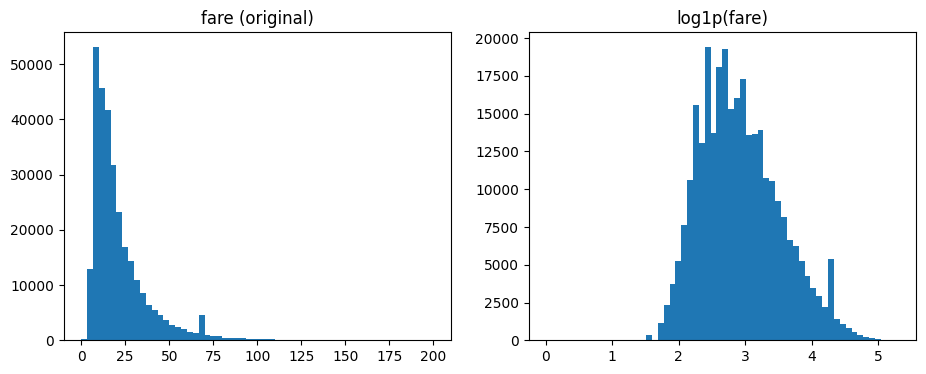

service
Green     13.50
Lyft      18.91
Uber      18.82
Yellow    13.86
Name: fare, dtype: float32


In [ ]:
from scipy.stats import skew

train = data[~data["is_test"]]
s = train.sample(300_000, random_state=1)

print("skew fare:", round(skew(s["fare"]), 2))
print("skew log1p(fare):", round(skew(np.log1p(s["fare"])), 2))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(s["fare"], bins=60); ax[0].set_title("fare (original)")
ax[1].hist(np.log1p(s["fare"]), bins=60); ax[1].set_title("log1p(fare)")
plt.show()

print(train.groupby("service", observed=True)["fare"].median().round(2))

### 7.2 Multicollinearity (VIF)
Airport flags are added (JFK, LaGuardia, Newark), then the Variance Inflation Factor is computed on a train sample. Every VIF is below 3 (rule of thumb: worry above 5-10), so **no feature needs to be dropped**.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# airport flags: JFK/LGA/EWR trips have special flat-rate pricing
data["is_airport_pu"] = data["PULocationID"].isin([1, 132, 138]).astype("int8")
data["is_airport_do"] = data["DOLocationID"].isin([1, 132, 138]).astype("int8")

num = ["est_distance", "avg_demand", "avg_speed", "hour", "day_of_week", "month",
       "is_weekend", "is_rush_hour", "temperature_2m", "precipitation", "snowfall",
       "wind_speed_10m", "cloud_cover", "is_raining", "is_snowing",
       "is_airport_pu", "is_airport_do"]

samp = data[~data["is_test"]].sample(200_000, random_state=1)[num].astype("float64")
X = add_constant(samp)
vif = pd.DataFrame({"feature": num,
                    "VIF": [variance_inflation_factor(X.values, i + 1) for i in range(len(num))]})
print(vif.sort_values("VIF", ascending=False).round(2).to_string(index=False))

       feature  VIF
    is_weekend 2.84
 is_airport_pu 2.74
   day_of_week 2.63
    is_snowing 2.24
      snowfall 2.22
     avg_speed 2.22
  est_distance 1.81
    avg_demand 1.69
    is_raining 1.61
 precipitation 1.46
 is_airport_do 1.34
  is_rush_hour 1.26
   cloud_cover 1.16
         month 1.12
          hour 1.12
temperature_2m 1.11
wind_speed_10m 1.10


## 8. Models

### 8.1 Feature matrix
- `hour` and `month` are circular, so they are encoded with sin/cos
- `service` becomes 0/1 columns (Yellow is the reference), plus a separate distance slope per service (Uber/Lyft price per mile differently from taxis)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# hour and month are circular (23:00 is next to 00:00, December is next to January) -> sin/cos
for col, n in [("hour", 24), ("month", 12)]:
    data[f"{col}_sin"] = np.sin(2 * np.pi * data[col] / n).astype("float32")
    data[f"{col}_cos"] = np.cos(2 * np.pi * data[col] / n).astype("float32")

# service as 0/1 columns (Yellow is the reference) + a separate distance slope per service
svc = pd.get_dummies(data["service"], prefix="svc", dtype="int8").drop(columns="svc_Yellow")
inter = svc.multiply(data["est_distance"], axis=0).add_prefix("dist_x_")

base = ["est_distance", "avg_demand", "avg_speed", "is_weekend", "is_rush_hour",
        "hour_sin", "hour_cos", "month_sin", "month_cos",
        "temperature_2m", "precipitation", "snowfall", "wind_speed_10m", "cloud_cover",
        "is_raining", "is_snowing", "is_airport_pu", "is_airport_do"]

X = pd.concat([data[base], svc, inter], axis=1).astype("float32")
y = np.log1p(data["fare"]).astype("float32")      # model the log of the fare (skew 2.38 -> 0.49)
mask = data["is_test"].values
print("features:", X.shape[1])

features: 24


### 8.2 OLS baseline
Features are standardised and cast to float64. (The very first attempt used float32 without scaling and scored R² = 0.017. The data was fine; it was a numerical precision problem.)

Train and test R² are almost identical (0.674 vs 0.671), so there is no overfitting.

In [ ]:
from sklearn.preprocessing import StandardScaler

# NOTE: features must be float64 and standardised. The first attempt used float32 without scaling
# and gave R2 = 0.017 (a numerical-precision problem, not a data problem).
Xtr = X[~mask].astype("float64"); Xte = X[mask].astype("float64")
ytr = y[~mask].astype("float64");  yte = y[mask].astype("float64")

sc = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = sc.transform(Xtr), sc.transform(Xte)

ols = LinearRegression().fit(Xtr_s, ytr)
p_tr, p_te = ols.predict(Xtr_s), ols.predict(Xte_s)

usd_true, usd_pred = np.expm1(yte), np.expm1(p_te)
print("R2 train:", round(r2_score(ytr, p_tr), 4))
print("R2 test :", round(r2_score(yte, p_te), 4))
print("RMSE ($):", round(mean_squared_error(usd_true, usd_pred) ** 0.5, 2))
print("MAE  ($):", round(mean_absolute_error(usd_true, usd_pred), 2))

err = pd.DataFrame({"service": data.loc[mask, "service"].values,
                    "abs_err": np.abs(usd_true.values - usd_pred)})
print(err.groupby("service", observed=True)["abs_err"].mean().round(2))

R2 train: 0.6742
R2 test : 0.6709
RMSE ($): 17.16
MAE  ($): 6.79
service
Green     5.52
Lyft      6.67
Uber      7.78
Yellow    6.35
Name: abs_err, dtype: float64


### 8.3 Ridge and Lasso
The regularisation strength is chosen by cross-validation. With about 4 million training rows and 24 features there is nothing to overfit, so **OLS, Ridge and Lasso give identical scores** and Lasso does not zero out any feature (it picked the smallest alpha in the grid). Regularisation is still useful insurance for the final model, which has more correlated distance terms.

What the coefficients show: distance dominates, weather effects are tiny (rain, snow, wind and cloud cover all have coefficients below 0.004), and higher average speed (less traffic) means a lower fare because the taxi meter also charges for waiting time.

In [ ]:
from sklearn.linear_model import RidgeCV, LassoCV, Ridge, Lasso

# choose the regularisation strength by cross-validation on a 300k train sample
idx = np.random.RandomState(1).choice(len(Xtr_s), 300_000, replace=False)
Xs, ys = Xtr_s[idx], ytr.values[idx]

ridge_cv = RidgeCV(alphas=[0.1, 1, 10, 100, 1000]).fit(Xs, ys)
lasso_cv = LassoCV(alphas=[1e-5, 1e-4, 1e-3, 1e-2], cv=3).fit(Xs, ys)
print("best alpha ridge:", ridge_cv.alpha_, "| lasso:", lasso_cv.alpha_)

models = {"OLS": ols,
          "Ridge": Ridge(alpha=ridge_cv.alpha_).fit(Xtr_s, ytr),
          "Lasso": Lasso(alpha=lasso_cv.alpha_).fit(Xtr_s, ytr)}

rows = []
for name, m in models.items():
    p = m.predict(Xte_s)
    rows.append({"model": name, "R2_test": round(r2_score(yte, p), 4),
                 "RMSE_$": round(mean_squared_error(np.expm1(yte), np.expm1(p)) ** 0.5, 2),
                 "MAE_$": round(mean_absolute_error(np.expm1(yte), np.expm1(p)), 2)})
print(pd.DataFrame(rows).to_string(index=False))

coef = pd.DataFrame({"feature": X.columns,
                     "OLS": models["OLS"].coef_,
                     "Ridge": models["Ridge"].coef_,
                     "Lasso": models["Lasso"].coef_}).round(4)
print("Features set to zero by Lasso:", (coef["Lasso"] == 0).sum())
print(coef.reindex(coef["OLS"].abs().sort_values(ascending=False).index).to_string(index=False))

best alpha ridge: 10.0 | lasso: 1e-05
model  R2_test  RMSE_$  MAE_$
  OLS   0.6709   17.16   6.79
Ridge   0.6709   17.16   6.79
Lasso   0.6709   17.16   6.79
Features set to zero by Lasso: 0
         feature     OLS   Ridge   Lasso
    est_distance  0.5459  0.5459  0.5458
        svc_Uber  0.1285  0.1285  0.1285
        svc_Lyft  0.1058  0.1057  0.1057
       avg_speed -0.0841 -0.0841 -0.0841
 dist_x_svc_Uber -0.0562 -0.0562 -0.0561
dist_x_svc_Green  0.0470  0.0470  0.0470
      avg_demand  0.0437  0.0437  0.0437
 dist_x_svc_Lyft -0.0352 -0.0352 -0.0351
   is_airport_do -0.0236 -0.0236 -0.0236
       month_sin -0.0138 -0.0138 -0.0137
    is_rush_hour -0.0088 -0.0088 -0.0087
        hour_sin  0.0068  0.0068  0.0068
  temperature_2m -0.0068 -0.0068 -0.0067
       month_cos -0.0062 -0.0062 -0.0061
        hour_cos -0.0057 -0.0057 -0.0056
      is_weekend -0.0052 -0.0052 -0.0052
   is_airport_pu -0.0047 -0.0047 -0.0046
        snowfall -0.0032 -0.0032 -0.0032
      is_raining  0.0024  0.00

### 8.4 Better distance terms (final model)
Fare against distance is not a straight line on the log scale, and the straight-line model had a large RMSE ($17) compared with its MAE ($6.8), meaning it failed badly on long trips. Adding `log(distance)`, `distance²` and a per-service log-distance slope fixes most of that: **RMSE drops from $17.16 to $8.82 and R² rises from 0.67 to 0.76.**

In [ ]:
# Fare vs distance is not a straight line on the log scale -> add log(distance) and distance^2
data["log_dist"] = np.log1p(data["est_distance"]).astype("float32")
data["dist_sq"] = (data["est_distance"] ** 2).astype("float32")
inter2 = svc.multiply(data["log_dist"], axis=0).add_prefix("logdist_x_")

X2 = pd.concat([X, data[["log_dist", "dist_sq"]], inter2], axis=1).astype("float64")
sc2 = StandardScaler().fit(X2[~mask])
X2tr, X2te = sc2.transform(X2[~mask]), sc2.transform(X2[mask])

m2 = Ridge(alpha=10).fit(X2tr, ytr)       # final model
p2 = m2.predict(X2te)

print("features:", X2.shape[1])
print("R2 test :", round(r2_score(yte, p2), 4))
print("RMSE ($):", round(mean_squared_error(np.expm1(yte), np.expm1(p2)) ** 0.5, 2))
print("MAE  ($):", round(mean_absolute_error(np.expm1(yte), np.expm1(p2)), 2))

features: 29
R2 test : 0.7584
RMSE ($): 8.82
MAE  ($): 4.93


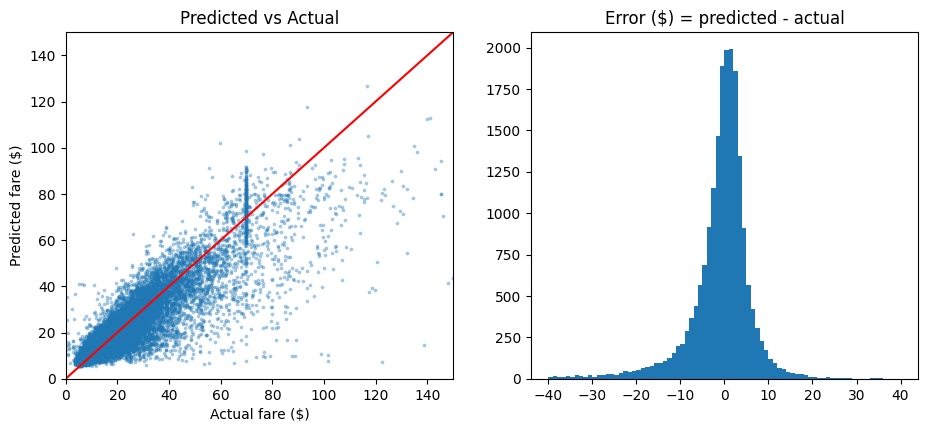

service
Green     3.77
Lyft      4.91
Uber      6.59
Yellow    3.70
Name: abs_err, dtype: float64
band
(0, 10]       2.61
(10, 20]      2.63
(20, 40]      5.85
(40, 80]     12.08
(80, 200]    36.57
Name: abs_err, dtype: float64


In [ ]:
sm = np.random.RandomState(1).choice(len(yte), 20000, replace=False)
a, p = np.expm1(yte.values[sm]), np.expm1(p2[sm])

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].scatter(a, p, s=3, alpha=0.3)
ax[0].plot([0, 150], [0, 150], "r")
ax[0].set_xlim(0, 150); ax[0].set_ylim(0, 150)
ax[0].set_xlabel("Actual fare ($)"); ax[0].set_ylabel("Predicted fare ($)")
ax[0].set_title("Predicted vs Actual")
ax[1].hist(p - a, bins=80, range=(-40, 40))
ax[1].set_title("Error ($) = predicted - actual")
plt.show()

e = pd.DataFrame({"service": data.loc[mask, "service"].values,
                  "actual": np.expm1(yte.values),
                  "abs_err": np.abs(np.expm1(yte.values) - np.expm1(p2))})
print(e.groupby("service", observed=True)["abs_err"].mean().round(2))
print(e.assign(band=pd.cut(e["actual"], [0, 10, 20, 40, 80, 200]))
        .groupby("band", observed=True)["abs_err"].mean().round(2))

## 10. Save the model for the app

In [ ]:
import joblib

joblib.dump({"model": m2, "scaler": sc2, "columns": list(X2.columns)},
            f"{folder}/model.joblib")
zones.to_csv(f"{folder}/zones.csv", index=False)

wm = (weather.assign(month=weather["time"].dt.month)
      .groupby("month")[["temperature_2m", "wind_speed_10m", "cloud_cover"]]
      .mean().round(2).reset_index())
wm.to_csv(f"{folder}/weather_monthly.csv", index=False)

print("saved model, zones, weather_monthly")
print(wm)

saved model, zones, weather_monthly
    month  temperature_2m  wind_speed_10m  cloud_cover
0       1        1.230000           13.99    64.489998
1       2        2.080000           12.94    47.279999
2       3        7.010000           15.05    61.310001
3       4       10.740000           14.69    65.540001
4       5       17.110001           11.96    69.589996
5       6       23.250000           13.38    55.880001
6       7       25.730000           11.01    60.650002
7       8       23.230000           11.59    49.820000
8       9       19.559999           11.09    54.279999
9      10       14.880000           11.81    31.850000
10     11        9.910000           12.17    44.180000
11     12        1.710000            9.22    55.650002
